In [5]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
likes = load_from_disk('dataset-parts/yambda_likes')
dislikes = load_from_disk('dataset-parts/yambda_dislikes')
# listens = load_from_disk('dataset-parts/yambda_listens')

likes_table = likes.data.table
dislikes_table = dislikes.data.table
# listens_table = listens.data.table


likes_df = likes_table.to_pandas()
dislikes_df = dislikes_table.to_pandas()
# listens_df = listens_table.to_pandas()

likes_df['event_type'] = 'like'
dislikes_df['event_type'] = 'dislike'
# listens_df['event_type'] = 'listen'

# yambda_df = pd.concat([likes_df, dislikes_df, listens_df], ignore_index=True)
yambda_df = pd.concat([likes_df, dislikes_df], ignore_index=True)

yambda_df = yambda_df.sort_values('timestamp')

yambda_df

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type
968657,794500,75,5559703,1,NaN,NaN,dislike
968664,794500,75,2224183,1,NaN,NaN,dislike
968663,794500,75,1861694,1,NaN,NaN,dislike
968662,794500,75,2605934,1,NaN,NaN,dislike
968661,794500,75,1113563,1,NaN,NaN,dislike
...,...,...,...,...,...,...,...
713215,809400,25999905,1264650,1,NaN,NaN,like
146824,168100,25999910,83561,1,NaN,NaN,like
360130,411500,25999945,1342000,1,NaN,NaN,like
933449,411500,25999945,6603749,1,NaN,NaN,dislike


In [3]:
yambda_df_organic = yambda_df[yambda_df['is_organic'] == 1].drop(['is_organic'], axis=1)

yambda_df_organic

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,event_type
968657,794500,75,5559703,NaN,NaN,dislike
968664,794500,75,2224183,NaN,NaN,dislike
968663,794500,75,1861694,NaN,NaN,dislike
968662,794500,75,2605934,NaN,NaN,dislike
968661,794500,75,1113563,NaN,NaN,dislike
...,...,...,...,...,...,...
146823,168100,25999890,4626898,NaN,NaN,like
713215,809400,25999905,1264650,NaN,NaN,like
146824,168100,25999910,83561,NaN,NaN,like
360130,411500,25999945,1342000,NaN,NaN,like


In [4]:
weak_ticks = (7 * 24 * 3600) // 5
year_ticks = (365 * 24 * 3600) // 5

weak_ticks, year_ticks

(120960, 6307200)

In [5]:
max_time = yambda_df_organic['timestamp'].max()

test_start = max_time - weak_ticks
train_start = test_start - year_ticks

In [6]:
train_df = yambda_df_organic[
    (yambda_df_organic['timestamp'] >= train_start) &
    (yambda_df_organic['timestamp'] < test_start)
]

test_df = yambda_df_organic[yambda_df_organic['timestamp'] >= test_start]

# Размер train/test и доли событий

In [8]:
print('Train rows:', len(train_df))
print('Test rows:', len(test_df))

print('\nTrain users/items:')
print('users =', train_df['uid'].nunique(), 'items =', train_df['item_id'].nunique())

print('\nTest users/items:')
print('users =', test_df['uid'].nunique(), 'items =', test_df['item_id'].nunique())

print('\nTrain event_type distribution:')
print(train_df['event_type'].value_counts())
print(train_df['event_type'].value_counts(normalize=True).round(4))

print('\nTest event_type distribution:')
print(test_df['event_type'].value_counts())
print(test_df['event_type'].value_counts(normalize=True).round(4))

Train rows: 188151
Test rows: 3848

Train users/items:
users = 7149 items = 73212

Test users/items:
users = 1295 items = 3342

Train event_type distribution:
event_type
like       171020
dislike     17131
Name: count, dtype: int64
event_type
like       0.909
dislike    0.091
Name: proportion, dtype: float64

Test event_type distribution:
event_type
like       3473
dislike     375
Name: count, dtype: int64
event_type
like       0.9025
dislike    0.0975
Name: proportion, dtype: float64


In [9]:
print('Train time range:')
print(train_df['timestamp'].min(), train_df['timestamp'].max())

print('\nTest time range:')
print(test_df['timestamp'].min(), test_df['timestamp'].max())

Train time range:
19571810 25878975

Test time range:
25879060 25999945


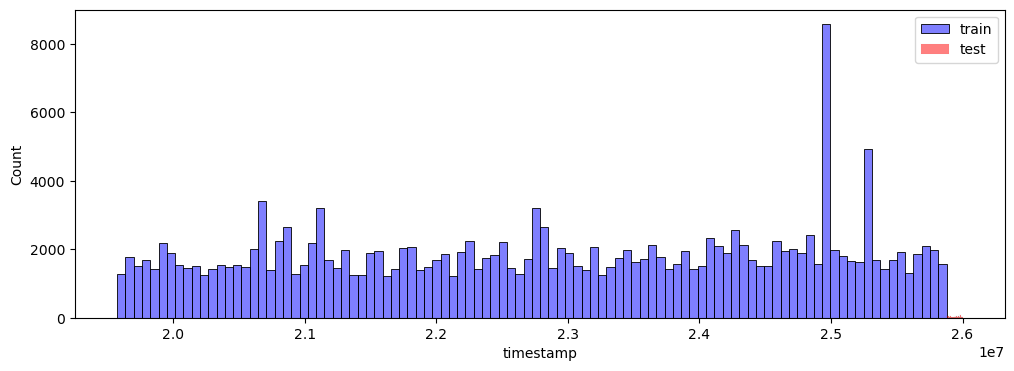

In [10]:
plt.figure(figsize=(12, 4))
sns.histplot(train_df['timestamp'], bins=100, color='blue', label='train', alpha=0.5)
sns.histplot(test_df['timestamp'], bins=100, color='red', label='test', alpha=0.5)
plt.legend()
plt.show()

Дневная динамика количества событий

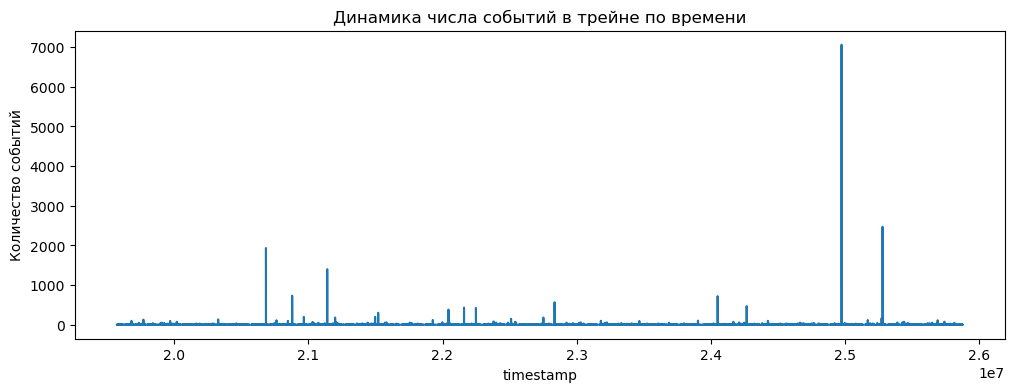

In [12]:
train_daily = (
    train_df.groupby('timestamp')
    .size()
    .reset_index(name='cnt')
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=train_daily, x='timestamp', y='cnt')
plt.title('Динамика числа событий в трейне по времени')
plt.xlabel('timestamp')
plt.ylabel('Количество событий')
plt.show()

Динамика лайков и дизлайков по времени

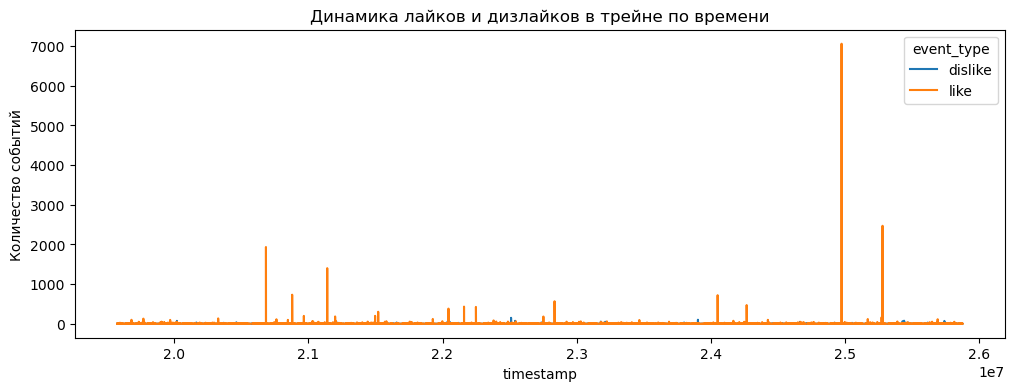

In [14]:
train_daily_by_type = (
    train_df.groupby(['timestamp', 'event_type'])
    .size()
    .reset_index(name='cnt')
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=train_daily_by_type, x='timestamp', y='cnt', hue='event_type')
plt.title('Динамика лайков и дизлайков в трейне по времени')
plt.xlabel('timestamp')
plt.ylabel('Количество событий')
plt.show()

Количество уникальных айтемов и пользователей

In [16]:
train_df['item_id'].nunique(), train_df['uid'].nunique()

(73212, 7149)

In [17]:
users_activity = train_df['uid'].value_counts()

In [18]:
users_activity.describe()

count    7149.000000
mean       26.318506
std       109.050893
min         1.000000
25%         3.000000
50%        10.000000
75%        25.000000
max      7184.000000
Name: count, dtype: float64

In [19]:
print('Топ-10 самых активных пользователей:')
print(users_activity.head(10))

print('\nДоля пользователей, имевших только одно взаимодействие:', (users_activity == 1).mean().round(4))
print('Доля пользователей с <= 5 взаимодействиями:', (users_activity <= 5).mean().round(4))
print('Доля пользователей с <= 10 взаимодействиями:', (users_activity <= 10).mean().round(4))
print('Доля пользователей с <= 25 взаимодействиями:', (users_activity <= 25).mean().round(4))
print('Доля пользователей с <= 50 взаимодействиями:', (users_activity <= 50).mean().round(4))

Топ-10 самых активных пользователей:
uid
763700    7184
964100    2747
301800    1961
898700    1411
227200    1411
333300    1129
342700     893
796000     843
87100      812
124200     793
Name: count, dtype: int64

Доля пользователей, имевших только одно взаимодействие: 0.1242
Доля пользователей с <= 5 взаимодействиями: 0.3591
Доля пользователей с <= 10 взаимодействиями: 0.5209
Доля пользователей с <= 25 взаимодействиями: 0.7531
Доля пользователей с <= 50 взаимодействиями: 0.8835


Длина истории пользователя

In [21]:
user_time_span = (
    train_df.groupby('uid')['timestamp']
    .agg(['min', 'max'])
    .assign(span=lambda x: x['max'] - x['min'])
)

user_time_span['span'].describe()

count    7.149000e+03
mean     3.400789e+06
std      2.218284e+06
min      0.000000e+00
25%      1.209575e+06
50%      4.018570e+06
75%      5.420815e+06
max      6.302335e+06
Name: span, dtype: float64

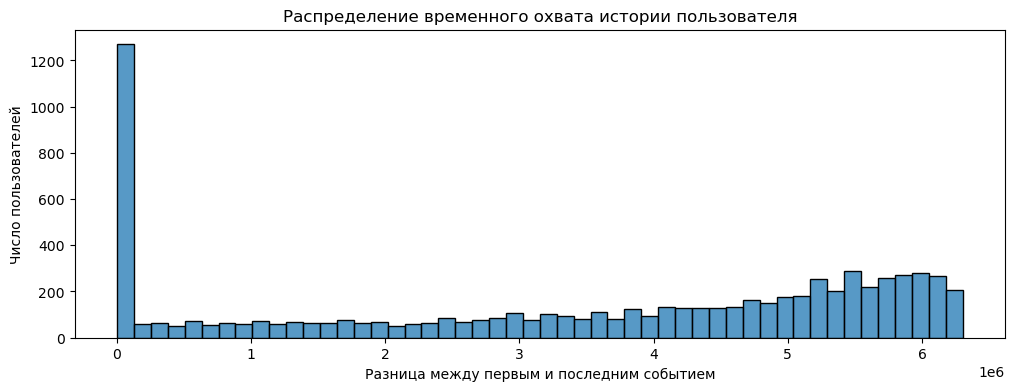

In [22]:
plt.figure(figsize=(12, 4))
sns.histplot(user_time_span['span'], bins=50)
plt.title('Распределение временного охвата истории пользователя')
plt.xlabel('Разница между первым и последним событием')
plt.ylabel('Число пользователей')
plt.show()

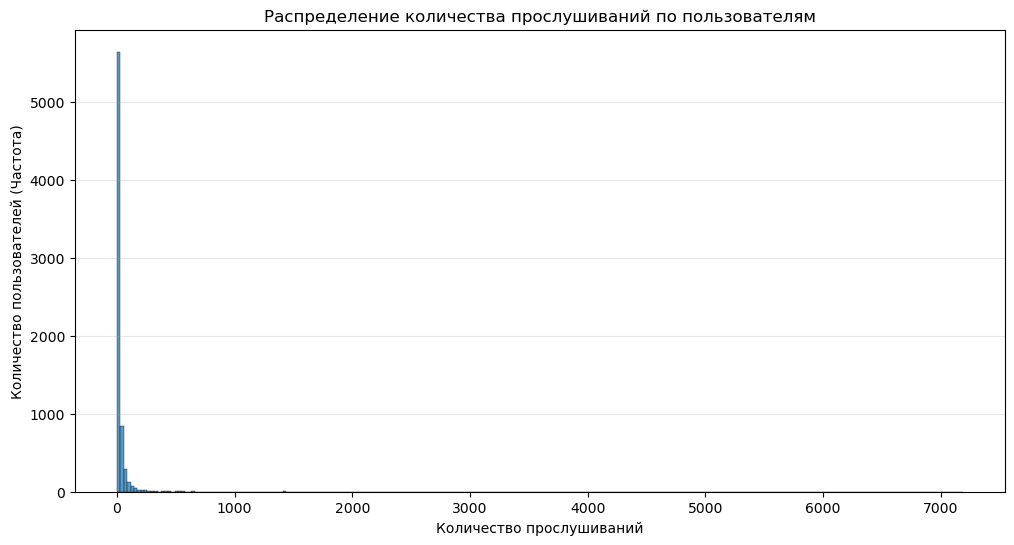

In [23]:
plt.figure(figsize=(12, 6))

sns.histplot(users_activity, bins=250)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='count'>

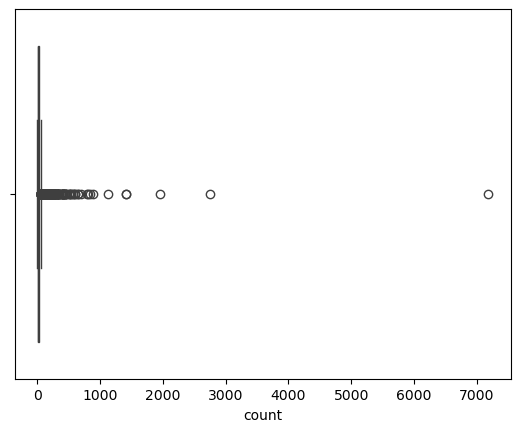

In [24]:
sns.boxplot(x=users_activity)

Распределение активности по айтемам

In [26]:
items_activity = train_df['item_id'].value_counts()
items_activity.describe()

count    73212.000000
mean         2.569948
std          5.723127
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        337.000000
Name: count, dtype: float64

Популярности айтемов

In [28]:
print('Топ-10 самых популярных айтемов:')
print(items_activity.head(10))

print('\nТоп-10 наименее популярных айтемов:')
print(items_activity.tail(10))

Топ-10 самых популярных айтемов:
item_id
3542184    337
6006390    243
2185191    226
8823268    207
5862961    200
5252571    190
6813373    181
2621516    171
2408923    171
8647463    170
Name: count, dtype: int64

Топ-10 наименее популярных айтемов:
item_id
7043386    1
2271861    1
8927095    1
7382461    1
848714     1
6586777    1
1778311    1
4455122    1
4544121    1
5954380    1
Name: count, dtype: int64


Длина жизни трека в данных

In [30]:
item_time_span = (
    train_df.groupby('item_id')['timestamp']
    .agg(['min', 'max'])
    .assign(span=lambda x: x['max'] - x['min'])
)

item_time_span['span'].describe()

count    7.321200e+04
mean     1.034187e+06
std      1.786547e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.505585e+06
max      6.303475e+06
Name: span, dtype: float64

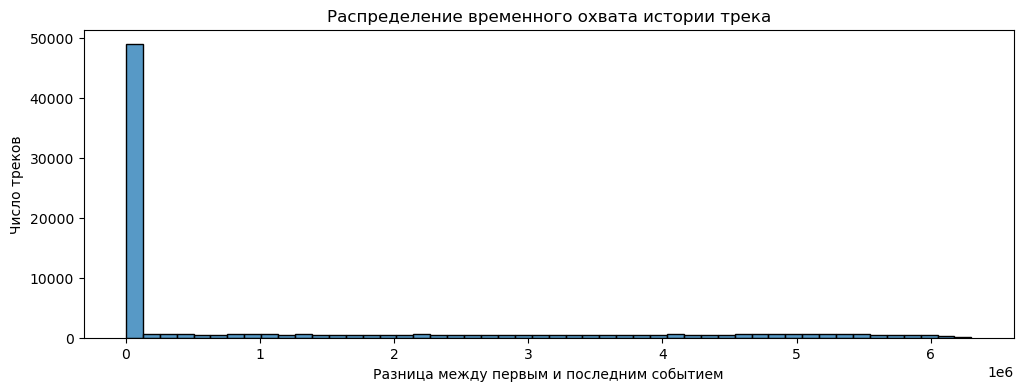

In [31]:
plt.figure(figsize=(12, 4))
sns.histplot(item_time_span['span'], bins=50)
plt.title('Распределение временного охвата истории трека')
plt.xlabel('Разница между первым и последним событием')
plt.ylabel('Число треков')
plt.show()

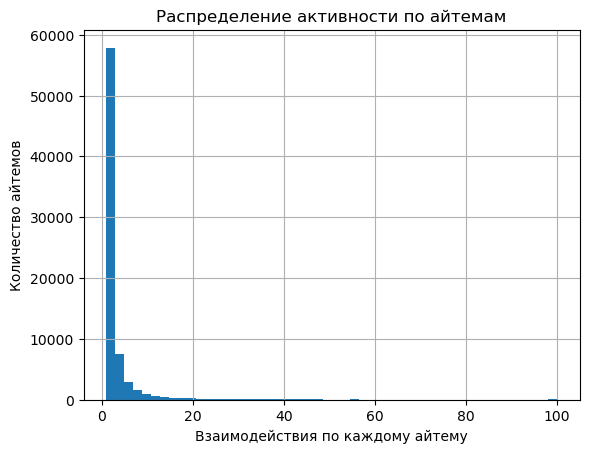

In [32]:
items_activity.clip(upper=100).hist(bins=50)
plt.title('Распределение активности по айтемам')
plt.xlabel('Взаимодействия по каждому айтему')
plt.ylabel('Количество айтемов')
plt.show()

In [33]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {users_activity.quantile(quantile)}')

Listens quntile 25.0%: 3.0
Listens quntile 50.0%: 10.0
Listens quntile 75.0%: 25.0
Listens quntile 80.0%: 31.0
Listens quntile 90.0%: 56.0
Listens quntile 95.0%: 90.0
Listens quntile 99.0%: 231.0799999999981
Listens quntile 99.9%: 838.4120000000239


In [34]:

groups = pd.qcut(users_activity, q=[0, 0.3, 0.6, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print('Users activity distribution')
print(counts)

Users activity distribution
count
(0.999, 4.0]      2258
(4.0, 14.0]       2075
(14.0, 56.0]      2116
(56.0, 90.0]       346
(90.0, 7184.0]     354
Name: count, dtype: int64


Можно увидеть, что активные/"нормальные" пользователи сидят между 60-ым 95-ым перцентилями, я бы даже поднял нижнюю границу до 70

In [36]:
low_threshold = users_activity.quantile(0.7)
high_threshold = users_activity.quantile(0.95)

active_user_ids = users_activity[
    (users_activity >= low_threshold) & 
    (users_activity <= high_threshold)
].index

df_train_active = train_df[train_df['uid'].isin(active_user_ids)].reset_index(drop=True)

In [37]:
df_train_active['uid'].value_counts().describe()

count    1809.000000
mean       40.697070
std        17.799771
min        21.000000
25%        26.000000
50%        35.000000
75%        51.000000
max        90.000000
Name: count, dtype: float64

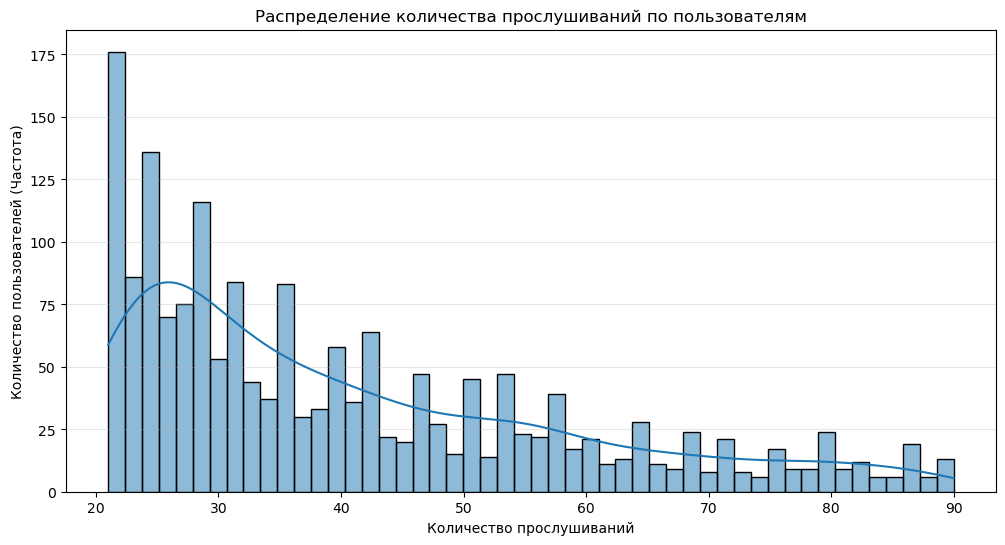

In [38]:
plt.figure(figsize=(12, 6))

sns.histplot(df_train_active['uid'].value_counts(), kde=True, bins=50)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

Стало получше. Мы убрали неактивных пользователей, убрали супер активных.

Может показаться странным, что за год люди слушали так мало треков, но эта статистика берется по данным с  explicit фидбеком, которого всегда меньше

In [40]:
df_train_active

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,event_type
0,627100,19571995,453808,NaN,NaN,dislike
1,349300,19572125,1949803,NaN,NaN,like
2,349300,19572125,219150,NaN,NaN,like
3,559100,19572260,1044085,NaN,NaN,like
4,559100,19572260,2033546,NaN,NaN,like
...,...,...,...,...,...,...
73616,488000,25878780,6317616,NaN,NaN,like
73617,488000,25878780,5302349,NaN,NaN,like
73618,32500,25878800,3135264,NaN,NaN,like
73619,32500,25878800,5016149,NaN,NaN,like


In [41]:
df_train_active.uid.nunique(), df_train_active.item_id.nunique()

(1809, 35620)

Насколько фильтр active users режет данные

In [43]:
print('Перед фильтрацией активных пользователей:')
print('rows =', len(train_df), 'users =', train_df['uid'].nunique(), 'items =', train_df['item_id'].nunique())

print('\nПосле фильтрации активных пользователей:')
print('rows =', len(df_train_active), 'users =', df_train_active['uid'].nunique(), 'items =', df_train_active['item_id'].nunique())

print('\nОставшаяся доля:')
print('rows =', round(len(df_train_active) / len(train_df), 4))
print('users =', round(df_train_active['uid'].nunique() / train_df['uid'].nunique(), 4))
print('items =', round(df_train_active['item_id'].nunique() / train_df['item_id'].nunique(), 4))

Перед фильтрацией активных пользователей:
rows = 188151 users = 7149 items = 73212

После фильтрации активных пользователей:
rows = 73621 users = 1809 items = 35620

Оставшаяся доля:
rows = 0.3913
users = 0.253
items = 0.4865


Что происходит с распределением event_type после фильтра активных

In [45]:
print('Обучение распределения event_type перед фильтрацией активных пользователей')
print(train_df['event_type'].value_counts(normalize=True).round(4))

print('\nОбучение распределения event_type после фильтрации активных пользователей:')
print(df_train_active['event_type'].value_counts(normalize=True).round(4))

Обучение распределения event_type перед фильтрацией активных пользователей
event_type
like       0.909
dislike    0.091
Name: proportion, dtype: float64

Обучение распределения event_type после фильтрации активных пользователей:
event_type
like       0.9189
dislike    0.0811
Name: proportion, dtype: float64


Сейчас у нас есть следующие формы взаимодействия:
* Лайк
* Дизлайк
* Прослушивание

Из них нужно сформировать разные матрицы взаимодействий: бинарные, знаковые, взвешанные

Пока что мы делали препроцессинг для лайков и дизлайков, поэтому попробуем поработать только с этими видами фидбека 

In [47]:
counts = df_train_active.groupby(['uid', 'item_id'])['item_id'].transform('size')

duplicates_full = df_train_active[counts > 1].sort_values(by=['uid', 'item_id'])

duplicates_full.uid.nunique()

928

Конфликтные пары uid-item

In [49]:
pair_event_stats = (
    df_train_active
    .groupby(['uid', 'item_id'])['event_type']
    .agg(
        n_events='count',
        n_unique_events='nunique',
        events=lambda x: tuple(sorted(set(x)))
    )
    .reset_index()
)

print('Пары с повторяющимися взаимодействиями:', (pair_event_stats['n_events'] > 1).sum())
print('Сочетается с конфликтующими типами событий.:', (pair_event_stats['n_unique_events'] > 1).sum())

pair_event_stats[pair_event_stats['n_unique_events'] > 1]['events'].value_counts().head(20)

Пары с повторяющимися взаимодействиями: 2344
Сочетается с конфликтующими типами событий.: 884


events
(dislike, like)    884
Name: count, dtype: int64

In [134]:
df_train_active.event_type.value_counts()

event_type
like       67654
dislike     5967
Name: count, dtype: int64

Тут видна такая ситуация: у нас 1809 пользователей, из которых тольо 928 совершали несколько действий (лайк и дизлайк), при этом большинство ставит лайки трекам. Думаю я сделаю такие взаимодействия: 
* значения -1 для дизлайков и 1 для лайков
* значения 0.1 для дизлайков и 1 для лайков. 

Для iALS буду использовать только 2-ой вариант, а для EASE, KNN попробую оба

In [52]:
train_df_sorted = train_df.sort_values(by=['uid', 'item_id', 'timestamp'])

final_states = train_df_sorted.drop_duplicates(subset=['uid', 'item_id'], keep='last').copy()

weight_mapping_sign = {
    'like': 1,
    'dislike': -1,
}

weight_mapping_weighted = {
    'like': 1,
    'dislike': 0.1,
}

final_states['interaction_sign'] = final_states['event_type'].map(weight_mapping_sign)
final_states['interaction_weighted'] = final_states['event_type'].map(weight_mapping_weighted)


user_item_sign = final_states[['uid', 'item_id', 'interaction_sign']].reset_index(drop=True)
user_item_weighted = final_states[['uid', 'item_id', 'interaction_weighted']].reset_index(drop=True)

In [53]:
user_item_sign.to_csv('user_item_sign_likes.csv')
user_item_weighted.to_csv('user_item_weighted_likes.csv')

In [54]:
train_users_sign = set(user_item_sign['uid'])
train_items_sign = set(user_item_sign['item_id'])

test_clean = test_df[
    test_df['uid'].isin(train_users_sign) &
    test_df['item_id'].isin(train_items_sign)
]

Доля cold-start в тесте

In [56]:
test_users_all = set(test_df['uid'])
test_items_all = set(test_df['item_id'])

train_users = set(user_item_sign['uid'])
train_items = set(user_item_sign['item_id'])

cold_users = test_df[~test_df['uid'].isin(train_users)]
cold_items = test_df[~test_df['item_id'].isin(train_items)]

print('Исходные тестовые строки:', len(test_df))
print('Чистые тестовые строки', len(test_clean))
print('Удалена тестовая доля:', round(1 - len(test_clean) / len(test_df), 4))

print('\nХолодные пользователи в тесте:', cold_users['uid'].nunique(), 'unique users')
print('Холодные айтемы в тесте:', cold_items['item_id'].nunique(), 'unique items')

print('\nДоля тестовых строк у невидимого пользователя:', round((~test_df['uid'].isin(train_users)).mean(), 4))
print('Доля тестовых строк с невидимым айтемом:', round((~test_df['item_id'].isin(train_items)).mean(), 4))

Исходные тестовые строки: 3848
Чистые тестовые строки 2663
Удалена тестовая доля: 0.308

Холодные пользователи в тесте: 35 unique users
Холодные айтемы в тесте: 1049 unique items

Доля тестовых строк у невидимого пользователя: 0.0327
Доля тестовых строк с невидимым айтемом: 0.2835


In [57]:
item2id = {k: v for v, k in enumerate(user_item_sign['item_id'].unique())}
user2id = {k: v for v, k in enumerate(user_item_sign['uid'].unique())}

id2item = {v: k for k, v in item2id.items()}
id2user = {v: k for k, v in user2id.items()}

In [58]:
user_item_sign['uidx'] = user_item_sign['uid'].map(user2id)
user_item_sign['item_idx'] = user_item_sign['item_id'].map(item2id)

user_item_weighted['uidx'] = user_item_weighted['uid'].map(user2id)
user_item_weighted['item_idx'] = user_item_weighted['item_id'].map(item2id)

In [59]:
user_item_sign

,uid,item_id,interaction_sign,uidx,item_idx
0,100,2263048,1,0,0
1,100,3526521,1,0,1
2,100,4927727,-1,0,2
3,100,5590855,1,0,3
4,300,1126058,1,1,4
...,...,...,...,...,...
177400,999900,1369814,1,7147,73211
177401,999900,1524105,1,7147,4486
177402,999900,2185191,1,7147,83
177403,999900,2467371,1,7147,25210


In [60]:
user_item_weighted

,uid,item_id,interaction_weighted,uidx,item_idx
0,100,2263048,1.0,0,0
1,100,3526521,1.0,0,1
2,100,4927727,0.1,0,2
3,100,5590855,1.0,0,3
4,300,1126058,1.0,1,4
...,...,...,...,...,...
177400,999900,1369814,1.0,7147,73211
177401,999900,1524105,1.0,7147,4486
177402,999900,2185191,1.0,7147,83
177403,999900,2467371,1.0,7147,25210


In [61]:
from scipy.sparse import csr_matrix

user_item_sign_sparse = csr_matrix(
    (
        user_item_sign['interaction_sign'],
        (user_item_sign['uidx'], user_item_sign['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

user_item_weighted_sparse = csr_matrix(
    (
        user_item_weighted['interaction_weighted'],
        (user_item_weighted['uidx'], user_item_weighted['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

Насколько разреженная матрица

In [63]:
n_users, n_items = user_item_sign_sparse.shape
nnz = user_item_sign_sparse.nnz
density = nnz / (n_users * n_items)

print('Matrix shape:', user_item_sign_sparse.shape)
print('Non-zero entries:', nnz)
print('Density:', density)
print('Sparsity:', 1 - density)

Matrix shape: (7149, 73212)
Non-zero entries: 177405
Density: 0.0003389520678500705
Sparsity: 0.9996610479321499


Metrics import 

In [65]:
from metrics import (
    recall_at_k,
    precision_at_k,
    ndcg_at_k,
    map_at_k,
    hit_rate_at_k,
)

Истинные взаимодействия, пока без разделения на лайки/дизлайки

In [67]:
test_true = test_clean.groupby('uid')['item_id'].apply(set).to_dict()

UserKNN

In [119]:
from models import UserKNN

In [121]:
userknn_sign = UserKNN()
userknn_sign.fit(user_item_sign_sparse)

In [123]:
userknn_weighted = UserKNN()
userknn_weighted.fit(user_item_weighted_sparse)

In [125]:
recall_userknn_sign = recall_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)
precision_userknn_sign = precision_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)
ndcg_userknn_sign = ndcg_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)
map_userknn_sign = map_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)
hit_rate_userknn_sign = hit_rate_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_sign.predict
)

print('UserKNN sign NDCG@10:', ndcg_userknn_sign)
print('UserKNN sign Recall@10:', recall_userknn_sign)
print('UserKNN sign Precision@10:', precision_userknn_sign)
print('UserKNN sign MAP@10:', map_userknn_sign)
print('UserKNN sign HitRate@10:', hit_rate_userknn_sign)


UserKNN sign NDCG@10: 0.018443302814498373
UserKNN sign Recall@10: 0.022605363984674328
UserKNN sign Precision@10: 0.005656759348034516
UserKNN sign MAP@10: 0.012550069244700117
UserKNN sign HitRate@10: 0.05081495685522531


In [126]:
recall_userknn_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
precision_userknn_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
ndcg_userknn_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
map_userknn_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)
hit_rate_userknn_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=userknn_weighted.predict
)

print('UserKNN weighted NDCG@10:', ndcg_userknn_weighted)
print('UserKNN weighted Recall@10:', recall_userknn_weighted)
print('UserKNN weighted Precision@10:', precision_userknn_weighted)
print('UserKNN weighted MAP@10:', map_userknn_weighted)
print('UserKNN weighted HitRate@10:', hit_rate_userknn_weighted)


UserKNN weighted NDCG@10: 0.01726529500171954
UserKNN weighted Recall@10: 0.022222222222222223
UserKNN weighted Precision@10: 0.005560882070949185
UserKNN weighted MAP@10: 0.011629232043302032
UserKNN weighted HitRate@10: 0.04985618408437201


ItemKNN

In [128]:
from models import ItemKNN

In [129]:
itemknn_sign = ItemKNN()
itemknn_sign.fit(user_item_sign_sparse)

MemoryError: Unable to allocate 39.9 GiB for an array with shape (73212, 73212) and data type float64

In [146]:
itemknn_weighted = ItemKNN()
itemknn_weighted.fit(user_item_weighted_sparse)

MemoryError: Unable to allocate 39.9 GiB for an array with shape (73212, 73212) and data type float64

In [148]:
recall_itemknn_sign = recall_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)
precision_itemknn_sign = precision_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)
ndcg_itemknn_sign = ndcg_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)
map_itemknn_sign = map_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)
hit_rate_itemknn_sign = hit_rate_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_sign.predict
)

print('ItemKNN sign NDCG@10:', ndcg_itemknn_sign)
print('ItemKNN sign Recall@10:', recall_itemknn_sign)
print('ItemKNN sign Precision@10:', precision_itemknn_sign)
print('ItemKNN sign MAP@10:', map_itemknn_sign)
print('ItemKNN sign HitRate@10:', hit_rate_itemknn_sign)


TypeError: unsupported operand type(s) for @: 'csr_matrix' and 'NoneType'

In [150]:
recall_itemknn_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
precision_itemknn_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
ndcg_itemknn_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
map_itemknn_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)
hit_rate_itemknn_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=itemknn_weighted.predict
)

print('ItemKNN weighted NDCG@10:', ndcg_itemknn_weighted)
print('ItemKNN weighted Recall@10:', recall_itemknn_weighted)
print('ItemKNN weighted Precision@10:', precision_itemknn_weighted)
print('ItemKNN weighted MAP@10:', map_itemknn_weighted)
print('ItemKNN weighted HitRate@10:', hit_rate_itemknn_weighted)


TypeError: unsupported operand type(s) for @: 'csr_matrix' and 'NoneType'

ELSA


In [153]:
from models import ELSA

In [155]:
elsa_sign = ELSA()
elsa_sign.fit(user_item_sign_sparse)


In [156]:
elsa_weighted = ELSA()
elsa_weighted.fit(user_item_weighted_sparse)


In [157]:
recall_elsa_sign = recall_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)
precision_elsa_sign = precision_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)
ndcg_elsa_sign = ndcg_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)
map_elsa_sign = map_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)
hit_rate_elsa_sign = hit_rate_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_sign.predict,
)

print('ELSA sign NDCG@10:', ndcg_elsa_sign)
print('ELSA sign Recall@10:', recall_elsa_sign)
print('ELSA sign Precision@10:', precision_elsa_sign)
print('ELSA sign MAP@10:', map_elsa_sign)
print('ELSA sign HitRate@10:', hit_rate_elsa_sign)


ELSA sign NDCG@10: 0.01863238787045758
ELSA sign Recall@10: 0.022222222222222223
ELSA sign Precision@10: 0.005560882070949185
ELSA sign MAP@10: 0.012591045366692538
ELSA sign HitRate@10: 0.05081495685522531


In [158]:
recall_elsa_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
precision_elsa_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
ndcg_elsa_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
map_elsa_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)
hit_rate_elsa_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=elsa_weighted.predict,
)

print('ELSA weighted NDCG@10:', ndcg_elsa_weighted)
print('ELSA weighted Recall@10:', recall_elsa_weighted)
print('ELSA weighted Precision@10:', precision_elsa_weighted)
print('ELSA weighted MAP@10:', map_elsa_weighted)
print('ELSA weighted HitRate@10:', hit_rate_elsa_weighted)


ELSA weighted NDCG@10: 0.01811666253678027
ELSA weighted Recall@10: 0.021839080459770115
ELSA weighted Precision@10: 0.005465004793863854
ELSA weighted MAP@10: 0.012373266980170142
ELSA weighted HitRate@10: 0.04793863854266539


iALS


In [160]:
from models import iALS

In [161]:
ials_sign = iALS()
ials_sign.fit(user_item_sign_sparse)

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [00:06<00:00,  3.63it/s]


In [162]:
ials_weighted = iALS()
ials_weighted.fit(user_item_weighted_sparse)

100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [00:07<00:00,  3.41it/s]


In [163]:
recall_ials_sign = recall_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)
precision_ials_sign = precision_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)
ndcg_ials_sign = ndcg_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)
map_ials_sign = map_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)
hit_rate_ials_sign = hit_rate_at_k(
    test_true,
    user_item_sign_sparse,
    user2id,
    id2item,
    recommend_fn=ials_sign.predict,
)

print('iALS sign NDCG@10:', ndcg_ials_sign)
print('iALS sign Recall@10:', recall_ials_sign)
print('iALS sign Precision@10:', precision_ials_sign)
print('iALS sign MAP@10:', map_ials_sign)
print('iALS sign HitRate@10:', hit_rate_ials_sign)


iALS sign NDCG@10: 0.016155826557738975
iALS sign Recall@10: 0.022605363984674328
iALS sign Precision@10: 0.005656759348034516
iALS sign MAP@10: 0.009623542183465481
iALS sign HitRate@10: 0.052732502396931925


In [164]:
recall_ials_weighted = recall_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
precision_ials_weighted = precision_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
ndcg_ials_weighted = ndcg_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
map_ials_weighted = map_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)
hit_rate_ials_weighted = hit_rate_at_k(
    test_true,
    user_item_weighted_sparse,
    user2id,
    id2item,
    recommend_fn=ials_weighted.predict,
)

print('iALS weighted NDCG@10:', ndcg_ials_weighted)
print('iALS weighted Recall@10:', recall_ials_weighted)
print('iALS weighted Precision@10:', precision_ials_weighted)
print('iALS weighted MAP@10:', map_ials_weighted)
print('iALS weighted HitRate@10:', hit_rate_ials_weighted)


iALS weighted NDCG@10: 0.01685125981769586
iALS weighted Recall@10: 0.024521072796934867
iALS weighted Precision@10: 0.006136145733461169
iALS weighted MAP@10: 0.009567100143562272
iALS weighted HitRate@10: 0.05752636625119847


TopPopular, TopPersonal, TopPersonal+TopPopular

In [166]:
from models import TopPopular, TopPersonal, TopPersonalTopPopular

top_popular_sign = TopPopular()
top_popular_sign.fit(user_item_sign_sparse)

top_popular_weighted = TopPopular()
top_popular_weighted.fit(user_item_weighted_sparse)

top_personal_sign = TopPersonal()
top_personal_sign.fit(user_item_sign_sparse)

top_personal_weighted = TopPersonal()
top_personal_weighted.fit(user_item_weighted_sparse)

hybrid_sign = TopPersonalTopPopular()
hybrid_sign.fit(user_item_sign_sparse)

hybrid_weighted = TopPersonalTopPopular()
hybrid_weighted.fit(user_item_weighted_sparse)


In [167]:
def print_metrics_all(label, model, R, k=10):
    fn = model.predict
    print(f"=== {label} ===")
    print(f"Recall@{k}:", recall_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"Precision@{k}:", precision_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"NDCG@{k}:", ndcg_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"MAP@{k}:", map_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print(f"HitRate@{k}:", hit_rate_at_k(test_true, R, user2id, id2item, k, recommend_fn=fn))
    print()


for name, m, R in [
    ("TopPopular sign", top_popular_sign, user_item_sign_sparse),
    ("TopPopular weighted", top_popular_weighted, user_item_weighted_sparse),
    ("TopPersonal sign", top_personal_sign, user_item_sign_sparse),
    ("TopPersonal weighted", top_personal_weighted, user_item_weighted_sparse),
    ("TopPersonal+TopPopular sign", hybrid_sign, user_item_sign_sparse),
    ("TopPersonal+TopPopular weighted", hybrid_weighted, user_item_weighted_sparse),
]:
    print_metrics_all(name, m, R)


=== TopPopular sign ===
Recall@10: 0.011494252873563218
Precision@10: 0.0028763183125599234
NDCG@10: 0.00662573987045693
MAP@10: 0.003507916216449294
HitRate@10: 0.02588686481303931

=== TopPopular weighted ===
Recall@10: 0.011877394636015325
Precision@10: 0.002972195589645254
NDCG@10: 0.00627244140578749
MAP@10: 0.002999365045545934
HitRate@10: 0.024928092042186004

=== TopPersonal sign ===
Recall@10: 0.022605363984674328
Precision@10: 0.005656759348034516
NDCG@10: 0.018443302814498373
MAP@10: 0.012550069244700117
HitRate@10: 0.05081495685522531

=== TopPersonal weighted ===
Recall@10: 0.022222222222222223
Precision@10: 0.005560882070949185
NDCG@10: 0.01726529500171954
MAP@10: 0.011629232043302032
HitRate@10: 0.04985618408437201

=== TopPersonal+TopPopular sign ===
Recall@10: 0.01800766283524904
Precision@10: 0.004506232023010546
NDCG@10: 0.016973189799163187
MAP@10: 0.012031704180553653
HitRate@10: 0.04314477468839885

=== TopPersonal+TopPopular weighted ===
Recall@10: 0.017624521072

In [150]:
from models import NMFModel, BPRModel, PMFModel, LightFMModel, SLIMModel

In [ ]:
nmf_sign = NMFModel()
nmf_sign.fit(user_item_sign_sparse)

In [ ]:
nmf_weighted = NMFModel()
nmf_weighted.fit(user_item_weighted_sparse)

In [ ]:
nmf_results = []

for name, model, R in [
    ("NMF sign", nmf_sign, user_item_sign_sparse),
    ("NMF weighted", nmf_weighted, user_item_weighted_sparse),
]:
    fn = model.predict
    nmf_results.append({
        "model": name,
        "Recall@10": recall_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "Precision@10": precision_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "NDCG@10": ndcg_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "MAP@10": map_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "HitRate@10": hit_rate_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
    })

nmf_results_df = pd.DataFrame(nmf_results)
nmf_results_df

In [172]:
bpr_sign = BPRModel()
bpr_sign.fit(user_item_sign_sparse)

100%|███████████████████████████████████████████████| 100/100 [00:01<00:00, 65.38it/s, train_auc=99.87%, skipped=1.21%]


In [138]:
bpr_weighted = BPRModel()
bpr_weighted.fit(user_item_weighted_sparse)

100%|███████████████████████████████████████████████| 100/100 [00:01<00:00, 60.02it/s, train_auc=99.87%, skipped=1.19%]


In [140]:
bpr_results = []

for name, model, R in [
    ("BPR sign", bpr_sign, user_item_sign_sparse),
    ("BPR weighted", bpr_weighted, user_item_weighted_sparse),
]:
    fn = model.predict
    bpr_results.append({
        "model": name,
        "Recall@10": recall_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "Precision@10": precision_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "NDCG@10": ndcg_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "MAP@10": map_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "HitRate@10": hit_rate_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
    })

bpr_results_df = pd.DataFrame(bpr_results)
bpr_results_df

,model,Recall@10,Precision@10,NDCG@10,MAP@10,HitRate@10
0,BPR sign,0.009962,0.002493,0.007565,0.004514,0.024928
1,BPR weighted,0.011111,0.002780,0.006675,0.003859,0.025887


In [174]:
pmf_sign = PMFModel()
pmf_sign.fit(user_item_sign_sparse)

In [175]:
pmf_weighted = PMFModel()
pmf_weighted.fit(user_item_weighted_sparse)

In [176]:
pmf_results = []

for name, model, R in [
    ("PMF sign", pmf_sign, user_item_sign_sparse),
    ("PMF weighted", pmf_weighted, user_item_weighted_sparse),
]:
    fn = model.predict
    pmf_results.append({
        "model": name,
        "Recall@10": recall_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "Precision@10": precision_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "NDCG@10": ndcg_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "MAP@10": map_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "HitRate@10": hit_rate_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
    })

pmf_results_df = pd.DataFrame(pmf_results)
pmf_results_df

,model,Recall@10,Precision@10,NDCG@10,MAP@10,HitRate@10
0,PMF sign,0.001533,0.000384,0.001065,0.000635,0.003835
1,PMF weighted,0.000000,0.000000,0.000000,0.000000,0.000000


In [152]:
lightfm_sign = LightFMModel()
lightfm_sign.fit(user_item_sign_sparse)

ModuleNotFoundError: No module named 'lightfm'

In [146]:
lightfm_weighted = LightFMModel()
lightfm_weighted.fit(user_item_weighted_sparse)

ModuleNotFoundError: No module named 'lightfm'

In [ ]:
lightfm_results = []

for name, model, R in [
    ("LightFM sign", lightfm_sign, user_item_sign_sparse),
    ("LightFM weighted", lightfm_weighted, user_item_weighted_sparse),
]:
    fn = model.predict
    lightfm_results.append({
        "model": name,
        "Recall@10": recall_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "Precision@10": precision_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "NDCG@10": ndcg_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "MAP@10": map_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "HitRate@10": hit_rate_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
    })

lightfm_results_df = pd.DataFrame(lightfm_results)
lightfm_results_df

In [164]:
slim_sign = SLIMModel()
slim_sign.fit(user_item_sign_sparse)

slim_weighted = SLIMModel()
slim_weighted.fit(user_item_weighted_sparse)

MemoryError: Unable to allocate 39.9 GiB for an array with shape (73212, 73212) and data type float64

In [ ]:
slim_results = []

for name, model, R in [
    ("SLIM sign", slim_sign, user_item_sign_sparse),
    ("SLIM weighted", slim_weighted, user_item_weighted_sparse),
]:
    fn = model.predict
    slim_results.append({
        "model": name,
        "Recall@10": recall_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "Precision@10": precision_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "NDCG@10": ndcg_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "MAP@10": map_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
        "HitRate@10": hit_rate_at_k(test_true, R, user2id, id2item, 10, recommend_fn=fn),
    })

slim_results_df = pd.DataFrame(slim_results)
slim_results_df

In [ ]:
results_extra_df = pd.concat(
    [
        nmf_results_df,
        bpr_results_df,
        pmf_results_df,
        lightfm_results_df,
        slim_results_df,
    ],
    ignore_index=True
)

results_extra_df.sort_values("NDCG@10", ascending=False)